# Marketing Channel ROI & Attribution Analysis (Anonymized)

**Confidentiality Notice**

This analysis was originally completed as part of a technical interview using proprietary company data.

To respect confidentiality:
- All datasets used here are **synthetically generated**
- Partner names, channels, and values are anonymized
- The methodology, logic, and conclusions reflect the original analysis

This notebook demonstrates analytical approach and business reasoning, not company-specific data.

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

users = np.arange(1, 5001)

clicks = pd.DataFrame({
    "user_id": np.random.choice(users, 12000),
    "partner": np.random.choice(["Partner A", "Partner B", "Partner C", "Partner D"], 12000),
    "channel": np.random.choice(["Search", "Social", "Affiliate", "Direct"], 12000),
    "click_date": pd.to_datetime("2024-01-01") +
                  pd.to_timedelta(np.random.randint(0, 120, 12000), unit="D"),
    "cost": np.random.uniform(5, 250, 12000)
})

conversions = clicks.sample(1500, random_state=42).copy()
conversions["conversion_date"] = (
    conversions["click_date"] +
    pd.to_timedelta(np.random.randint(1, 90, 1500), unit="D")
)

#### Install Packages and Import Data
To set up the environment, run the following two cells. Setting everything up may take a few moments.

Do not alter any of the code in the next two cells.

In [5]:
%%capture

pip install pandas
pip install jupysql
pip install matplotlib
pip install click
pip install seaborn
pip install scipy

SyntaxError: invalid syntax (2806871526.py, line 1)

In [6]:
import matplotlib.pyplot as plt
import sys
import seaborn as sns
import scipy.stats as stats
import pandas as pd
import numpy as np
import os

# Ensure the images folder exists for saved plots
IMAGES_DIR = "../images"
os.makedirs(IMAGES_DIR, exist_ok=True)

sys.executable

'c:\\Users\\bilal\\Documents\\Workspace\\myenv\\Scripts\\python.exe'

In [7]:
%%capture

ad_channel_path="../data/ad_channels.csv"
clicks_path="../data/clicks.csv"
locks_path="../data/locks.csv"
sales_path="../data/sales.csv"
spend_path="../data/spend.csv"
vehicle_path="../data/vehicles.csv"

ad_channels=pd.read_csv(ad_channel_path)
clicks=pd.read_csv(clicks_path)
locks=pd.read_csv(locks_path)
sales=pd.read_csv(sales_path)
spend=pd.read_csv(spend_path)
vehicles=pd.read_csv(vehicle_path)

%load_ext sql
%sql sqlite://

%sql --persist ad_channels
%sql --persist clicks
%sql --persist locks
%sql --persist sales
%sql --persist spend
%sql --persist vehicles

______________________________________________________
______________________________________________________

In [8]:
df_ad_channels = ad_channels
df_ad_channels[['category','partner']]=df_ad_channels['channel'].str.split('-',expand=True)
df_ad_channels[['partner','campaign']]=df_ad_channels['partner'].str.split('_',expand=True)
df_ad_channels['campaign']= df_ad_channels['campaign'].fillna(ad_channels['partner'])
df_ad_channels.head()

,channel_id,channel,category,partner,campaign
0,1,Search Engine-SearchPartnerA_Convertible,Search Engine,SearchPartnerA,Convertible
1,2,Search Engine-SearchPartnerA_Sedan,Search Engine,SearchPartnerA,Sedan
2,3,Search Engine-SearchPartnerA_Truck,Search Engine,SearchPartnerA,Truck
3,4,Search Engine-SearchPartnerB_Convertible,Search Engine,SearchPartnerB,Convertible
4,5,Search Engine-SearchPartnerB_Sedan,Search Engine,SearchPartnerB,Sedan


In [9]:
x =ad_channels['partner'].count()
y= ad_channels['campaign'].count()
print(x,y)

16 16


In [10]:
df_clicks = clicks
df_clicks.dtypes

click_datetime      str
channel_id        int64
user_id           int64
dtype: object

In [11]:
## first touch attribution

df_first_touch = clicks
df_first_touch['click_datetime']=pd.to_datetime(clicks['click_datetime'])
df_first_touch = df_first_touch.sort_values(by='click_datetime',ascending=True)
df_first_touch= df_first_touch.drop_duplicates(subset = 'user_id',keep='first')
df_first_touch = pd.merge(df_first_touch,ad_channels,on='channel_id',how='left')

In [12]:

def margin(row):
    modifier = -0.1
    dist = row['delivery_distance']
    trade_in = row['has_trade_in']
    bodystyle = str(row['bodystyle']).lower
    margin = row['avg_margin']

    if row['is_financed']==1:
        modifier = (row['apr'] / row['monthly_avg_apr'] ) -1

    margin  *= (1+modifier)

    if bodystyle in ['sedan','hatchback']:
        margin = margin + 200 - dist/2
        if trade_in==1: margin += 400

    elif bodystyle in ['coupe','suv']:
        margin -= 0.8*dist
        if trade_in==1: margin += 300

    elif bodystyle == 'truck':
        margin = margin - 200 - dist
        if trade_in==1: margin += 200

    return round(margin,2)


## Calculating sales margin

df_master = sales
df_master['sale_datetime']=pd.to_datetime(df_master['sale_datetime'])
df_master['month']=df_master['sale_datetime'].dt.to_period('M')

df_monthly_average_apr = df_master[df_master['is_financed']==1].groupby('month')['apr'].mean().reset_index()
df_monthly_average_apr = df_monthly_average_apr.rename(columns={'apr':'monthly_avg_apr'})

df_master = pd.merge(df_master,df_monthly_average_apr,on='month',how='left')

df_master = pd.merge(df_master, vehicles, on=['make','model'],how='left')

df_master['sale_margin'] = df_master.apply(margin, axis=1)

df_master.head()

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,month,monthly_avg_apr,bodystyle,avg_margin,sale_margin
0,10146928.0,523688,2022-09-14 20:13:00,801050,Honda,Civic,1,0,NaN,719,2022-09,0.087289,Sedan,728.37,655.53
1,10272031.0,526152,2022-09-27 21:28:00,800986,Toyota,Tacoma,0,1,0.131,388,2022-09,0.087289,Truck,202.64,304.11
2,10062937.0,507748,2022-09-20 20:14:00,802252,Jeep,Wrangler,0,0,NaN,350,2022-09,0.087289,SUV,318.42,286.58
3,10102762.0,527104,2022-09-15 19:31:00,800990,Mercedes-Benz,GLC,0,0,NaN,1057,2022-09,0.087289,SUV,711.24,640.12
4,10184845.0,507332,2022-09-11 21:53:00,801980,Mercedes-Benz,GLC,1,0,NaN,184,2022-09,0.087289,SUV,711.24,640.12


In [13]:
# marketing analysis
df_master = pd.merge(df_master,df_first_touch,on='user_id',how='left')

df_master.head()

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,...,monthly_avg_apr,bodystyle,avg_margin,sale_margin,click_datetime,channel_id,channel,category,partner,campaign
0,10146928.0,523688,2022-09-14 20:13:00,801050,Honda,Civic,1,0,NaN,719,...,0.087289,Sedan,728.37,655.53,2022-07-03 10:04:40,8.0,Online Video-VideoPlatformA_25+,Online Video,VideoPlatformA,25+
1,10272031.0,526152,2022-09-27 21:28:00,800986,Toyota,Tacoma,0,1,0.131,388,...,0.087289,Truck,202.64,304.11,2022-08-30 01:17:22,11.0,Finance Partnership-FinancePartnerA,Finance Partnership,FinancePartnerA,FinancePartnerA
2,10062937.0,507748,2022-09-20 20:14:00,802252,Jeep,Wrangler,0,0,NaN,350,...,0.087289,SUV,318.42,286.58,2022-06-21 14:10:00,11.0,Finance Partnership-FinancePartnerA,Finance Partnership,FinancePartnerA,FinancePartnerA
3,10102762.0,527104,2022-09-15 19:31:00,800990,Mercedes-Benz,GLC,0,0,NaN,1057,...,0.087289,SUV,711.24,640.12,2022-07-15 08:00:20,2.0,Search Engine-SearchPartnerA_Sedan,Search Engine,SearchPartnerA,Sedan
4,10184845.0,507332,2022-09-11 21:53:00,801980,Mercedes-Benz,GLC,1,0,NaN,184,...,0.087289,SUV,711.24,640.12,NaT,NaN,NaN,NaN,NaN,NaN


In [14]:
channel_values = df_master.groupby('channel_id').agg(
    total_sales = ('sale_id','count'),
    total_profit = ('sale_margin','sum')
    ).reset_index()

channel_spend = spend.groupby('channel_id').agg(
    total_spend = ('spend','sum'))

df_final = pd.merge(channel_spend,channel_values,on='channel_id',how='left')

channel_clicks= df_clicks.groupby('channel_id').agg(
    channel_clicks = ('click_datetime','count')
    ).reset_index()
df_final = pd.merge(df_final,channel_clicks,on='channel_id',how='left')

df_final['total_profit']=round(df_final['total_profit'],2).fillna(0)
df_final['total_sales']=round(df_final['total_sales'],2).fillna(0)
df_final['total_spend']=round(df_final['total_spend'],2).fillna(0)


df_final['total_profit_after_adspend']=round(df_final['total_profit'] - df_final['total_spend'],2)
df_final = pd.merge(df_final,df_ad_channels,on='channel_id',how='left')

df_final['CPC']= round(df_final['total_spend'] / df_final['channel_clicks'],2)
df_final['CAC'] = round(df_final['total_spend'] / df_final['total_sales'],2)
df_final['ROI'] = round(df_final['total_profit'] / df_final['total_spend'],2)
df_final['ROI_true'] = round(df_final['total_profit_after_adspend'] / df_final['total_spend'],2)
df_final.sort_values('channel_id')

,channel_id,total_spend,total_sales,total_profit,channel_clicks,total_profit_after_adspend,channel,category,partner,campaign,CPC,CAC,ROI,ROI_true
0,1,24999.95,135,62369.77,20977,37369.82,Search Engine-SearchPartnerA_Convertible,Search Engine,SearchPartnerA,Convertible,1.19,185.18,2.49,1.49
1,2,29999.95,174,89546.99,29324,59547.04,Search Engine-SearchPartnerA_Sedan,Search Engine,SearchPartnerA,Sedan,1.02,172.41,2.98,1.98
2,3,25000.15,114,56427.57,15392,31427.42,Search Engine-SearchPartnerA_Truck,Search Engine,SearchPartnerA,Truck,1.62,219.30,2.26,1.26
3,4,11999.94,52,27490.92,6835,15490.98,Search Engine-SearchPartnerB_Convertible,Search Engine,SearchPartnerB,Convertible,1.76,230.77,2.29,1.29
4,5,14999.98,91,48407.36,12182,33407.38,Search Engine-SearchPartnerB_Sedan,Search Engine,SearchPartnerB,Sedan,1.23,164.83,3.23,2.23
5,6,12000.12,38,18216.76,9881,6216.64,Search Engine-SearchPartnerB_Truck,Search Engine,SearchPartnerB,Truck,1.21,315.79,1.52,0.52
6,7,5000.04,8,4771.94,2505,-228.10,Online Video-VideoPlatformA_Teen,Online Video,VideoPlatformA,Teen,2.00,625.00,0.95,-0.05
7,8,14999.98,90,41786.51,7265,26786.53,Online Video-VideoPlatformA_25+,Online Video,VideoPlatformA,25+,2.06,166.67,2.79,1.79
8,9,5000.00,6,3530.57,2370,-1469.43,Online Video-VideoPlatformB_Teen,Online Video,VideoPlatformB,Teen,2.11,833.33,0.71,-0.29
9,10,14500.04,85,40901.11,6343,26401.07,Online Video-VideoPlatformB_25+,Online Video,VideoPlatformB,25+,2.29,170.59,2.82,1.82


In [15]:
def df_aggregator(df, indicator, sorter='CPC',asctrue=True):
    df_category = df.groupby(indicator).agg(
        total_sales = ('total_sales','sum'),
        total_profit = ('total_profit','sum'),
        total_spend = ('total_spend','sum'),
        total_clicks = ('channel_clicks','sum'),
        total_profit_after_adspend = ('total_profit_after_adspend','sum')
    ).reset_index()


    df_category['CPC']= round(df_category['total_spend'] / df_category['total_clicks'],2)
    df_category['CAC'] = round(df_category['total_spend'] / df_category['total_sales'],2)
    df_category['ROI'] = round(df_category['total_profit'] / df_category['total_spend'],2)
    df_category['ROI_true'] = round(df_category['total_profit_after_adspend'] / df_category['total_spend'],2)
    return df_category.sort_values(sorter,ascending=asctrue)

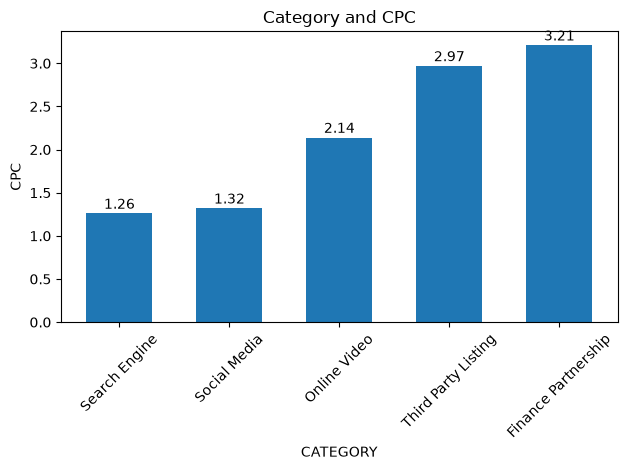

In [16]:
# Part 1
q1_category = df_aggregator(df_final,'category')
x = 'category'
y='CPC'

fig = plt.bar(x,y,  data=q1_category, width=0.6)
plt.xlabel(x.upper())
plt.ylabel(y)
plt.xticks(rotation=45)
plt.bar_label(fig,
              labels = [v for v in q1_category[y]],
              padding=1)

plt.title('Category and CPC')
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/part1_category_cpc.png", dpi=150, bbox_inches="tight")
plt.show()

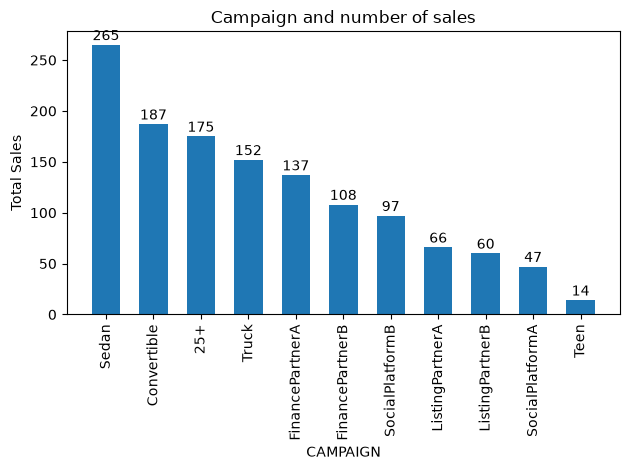

In [17]:
# Part 2
q2_campaign = df_aggregator(df_final,'campaign','total_sales',False)
x = 'campaign'
y='total_sales'

fig = plt.bar(x,y,  data=q2_campaign, width=0.6)
plt.xlabel(x.upper())
plt.ylabel('Total Sales')
plt.xticks(rotation='vertical')
plt.bar_label(fig,
              labels = [v for v in q2_campaign[y]],
              padding=1)

plt.title('Campaign and number of sales')
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/part2_campaign_sales.png", dpi=150, bbox_inches="tight")
plt.show()

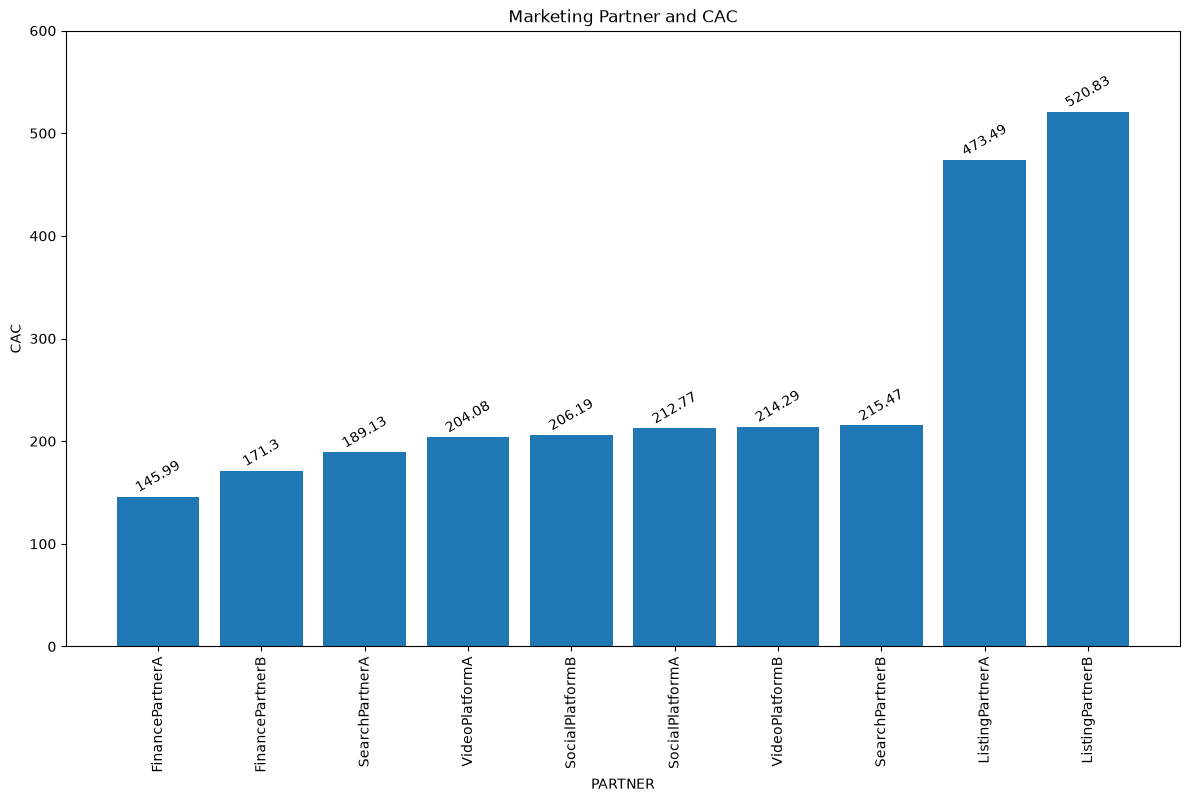

In [18]:
# Part 3

x ='partner'
y='CAC'
q3_partner = df_aggregator(df_final,x,y)
fig, ax=plt.subplots(figsize=(12,8))
bars = ax.bar(x,y,  data=q3_partner, width=0.8)
ax.set_xlabel(x.upper())
ax.set_ylabel(y)
plt.xticks(rotation='vertical')
ax.bar_label(bars,
              labels = [v for v in q3_partner[y]],
              padding=1,rotation=30)
plt.tight_layout()
plt.ylim(0,600)

plt.title('Marketing Partner and CAC')
plt.savefig(f"{IMAGES_DIR}/part3_partner_cac.png", dpi=150, bbox_inches="tight")
plt.show()

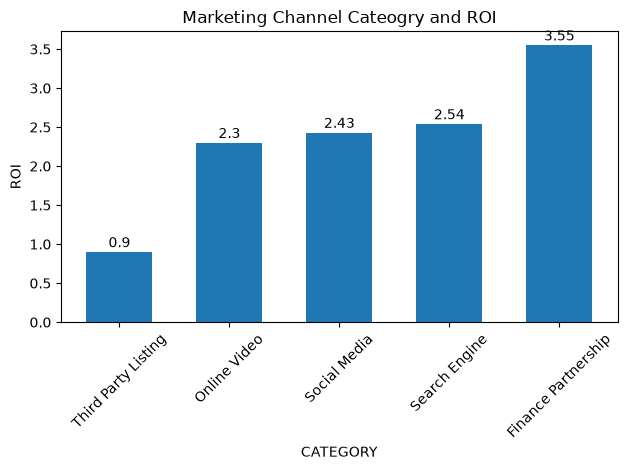

In [19]:
# Part 4
x = 'category'
y='ROI'
q4_category = df_aggregator(df_final,'category','ROI')


fig = plt.bar(x,y,  data=q4_category, width=0.6)
plt.xlabel(x.upper())
plt.ylabel(y)
plt.xticks(rotation=45)
plt.bar_label(fig,
              labels = [v for v in q4_category[y]],
              padding=1)

plt.title('Marketing Channel Cateogry and ROI')
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/part4_category_roi.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Part 5
df_click_lock = pd.merge(clicks, locks, on='user_id',how='left')

df_click_lock['locked'] = df_click_lock['lock_id'].isna()

df_dropped = df_click_lock[df_click_lock['locked']==True]
df_dropped = df_dropped.drop(columns=['lock_id','locked','lock_datetime'])
df_dropped['interaction'] = df_dropped.sort_values(['click_datetime']).groupby('user_id').cumcount()+1



df_locked = df_click_lock[df_click_lock['locked']==False]
df_locked = df_locked.drop(columns='locked')
df_locked['lock_datetime']=pd.to_datetime(df_locked['lock_datetime'],format = 'mixed')
df_locked['interaction']=df_locked.sort_values(['click_datetime']).groupby('lock_id').cumcount()+1

df_locked_stats = df_locked.groupby('lock_id').agg(
    clicks = ('click_datetime','count'),
    first_channel = ('channel_id','first'),
    last_channel =  ('channel_id','last'),
    channels_interacted = ('channel_id','nunique'),
)

df_dropped_stats = df_dropped.groupby('user_id').agg(
    clicks = ('click_datetime','count'),
    first_channel = ('channel_id','first'),
    last_channel =  ('channel_id','last'),
    channels_interacted = ('channel_id','nunique'),
)

# journey
df_locked_stats['journey'] = df_locked_stats['first_channel'].astype(str)+'to'+df_locked_stats['last_channel'].astype(str)
df_dropped_stats['journey'] = df_dropped_stats['first_channel'].astype(str)+'to'+df_dropped_stats['last_channel'].astype(str)

df_locked_stats['same_channel_lock']=df_locked_stats['first_channel']==df_locked_stats['last_channel']
df_dropped_stats['journey'].value_counts()
df_locked_stats['journey'].value_counts()
interaction_stats = df_locked_stats['channels_interacted'].value_counts()

interaction_stats.describe()
df_locked_excludingtesters = df_locked_stats[df_locked_stats['clicks']<20]
df_locked_differentpathway = df_locked_stats[df_locked_stats['same_channel_lock']==False]
df_locked_stats[df_locked_stats['same_channel_lock']==False]['journey'].value_counts()

journey
2to1     346
1to2     311
1to5     136
2to5     135
5to2     125
        ... 
9to2       1
9to14      1
9to15      1
7to6       1
7to12      1
Name: count, Length: 235, dtype: int64

In [21]:
# Part 6
locks['lock_datetime']=pd.to_datetime(locks['lock_datetime'],format = 'mixed')
df_master = pd.merge(df_master,locks[['lock_id','lock_datetime']],
                            on='lock_id',
                            how='left')

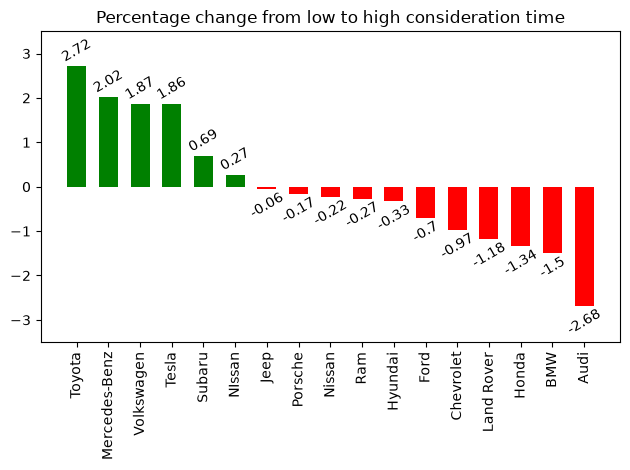

In [22]:
df_master['click_to_sale_days']= (df_master['sale_datetime'] - df_master['click_datetime']).dt.days
df_master['lock_to_sale_days']= (df_master['sale_datetime'] - df_master['lock_datetime']).dt.days
df_master['gt90'] = df_master['click_to_sale_days']>90
df_master['le90'] = df_master['click_to_sale_days']<=90


sales_gt_90 = df_master[df_master['gt90']==True]
sales_le_90 = df_master[df_master['gt90']==False]
sales_no_click = df_master[df_master['click_to_sale_days'].isna() == True]

# comparing make
make = df_master.groupby('make').agg(
    le90_freq = ('le90','sum'),
    gt90_freq = ('gt90','sum')
).reset_index()

make['le90_percent'] = 100* (make['le90_freq']/make['le90_freq'].sum())
make['gt90_percent'] = 100*( make['gt90_freq']/make['gt90_freq'].sum())
make['percent_delta'] = make['gt90_percent'] - make['le90_percent']
make=make.sort_values('percent_delta',ascending=False)
x = make['make'].astype(str)
y = make['percent_delta']
colors = ['green' if v>0 else 'red' for v in y]
fig = plt.bar(x,y, width=0.6, color=colors)
plt.xticks(rotation='vertical')
plt.bar_label(fig,
              labels = round(y,2),
              padding=1,rotation=30)
plt.title('Percentage change from low to high consideration time')
plt.ylim(-3.5,3.5)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/part6_make_consideration_time.png", dpi=150, bbox_inches="tight")
plt.show()

327


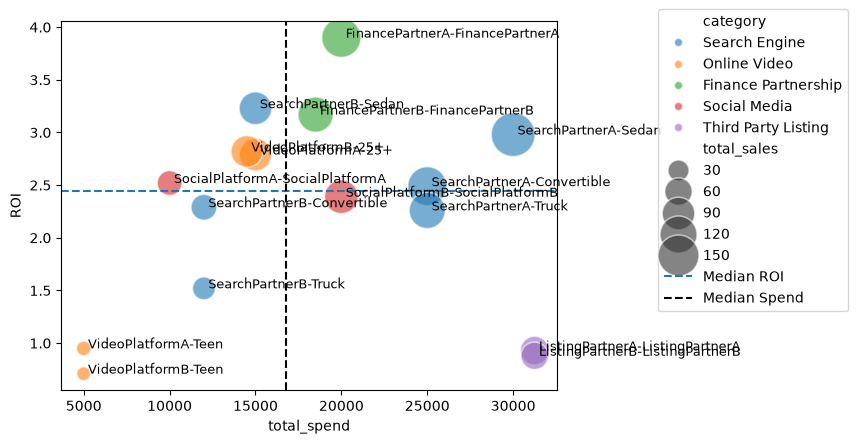

In [23]:
# Part 7

df_master['click_to_lock_days'] = (df_master['lock_datetime']-df_master['click_datetime']).dt.days
print((df_master['click_to_lock_days']>90).sum())

#  all channel analysis
## scatter plot for ROI vs spend
scatter = sns.scatterplot(
    data=df_final,
    x='total_spend',
    y='ROI',
    size='total_sales',
    sizes=(100,1000),
    hue='category',
    alpha = 0.6

)
for i in range(df_final.shape[0]):
    plt.text(
        x=df_final.total_spend[i] + 250,
        y = df_final.ROI[i] ,
        s = df_final.partner[i]+ '-'+df_final.campaign[i],
        fontsize = 9
    )

plt.axhline(y=df_final['ROI'].median(), linestyle = '--', label='Median ROI')
plt.axvline(x=df_final['total_spend'].median(), linestyle = '--', label='Median Spend', color = 'black')
plt.legend(bbox_to_anchor = (1.6,1.05),loc='upper right')
plt.savefig(f"{IMAGES_DIR}/part7_roi_vs_spend_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
## does increasing spend increase sales?

sales_channel = df_master[df_master['click_datetime'].isna()==False]
sales_channel['week_start']=sales_channel['sale_datetime'].dt.to_period('W').dt.start_time


weekly_sales = sales_channel.groupby(['channel_id','week_start']).size().reset_index(name='sales')
# weekly_clicks = sales_channel.groupby(['channel_id','week_start']).size().reset_index(name='clicks')

df_spend = spend
df_spend['date']=pd.to_datetime(df_spend['date'])
df_spend['week_start'] = df_spend['date'].dt.to_period('W').dt.start_time
weekly_spend = round(df_spend.groupby(['channel_id','week_start'])['spend'].sum().reset_index(name='spend'),2)

weekly_agg = pd.merge(weekly_sales,weekly_spend, on=['channel_id','week_start'], how = 'outer')
weekly_agg['spend'] = weekly_agg['spend'].fillna(0)
weekly_agg['sales'] = weekly_agg['sales'].fillna(0)

channel_num = weekly_agg['channel_id'].unique()
stats_results = []
for id in channel_num:
    channel_data = weekly_agg[weekly_agg['channel_id']==id]
    x = channel_data['spend']
    y= channel_data['sales']
    t_stat=0
    slope,intercept,r,p,se=stats.linregress(x,y)

    if se != 0:
        t = slope/se
    else:
        t = np.nan

    stats_results.append({
        'channel_id': id,
        'T-Stat': round(t,2),
        'p-value':round(p,4),
        'slope':round(slope,5),
        'R2': round(r**2,3)
    })
stats_results = pd.DataFrame(stats_results)
stats_results = pd.merge(stats_results,ad_channels, on='channel_id', how='left')
stats_results = stats_results.sort_values('p-value', ascending=True)

C:\Users\bilal\AppData\Local\Temp\ipykernel_11412\1461573419.py:13: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  weekly_spend = round(df_spend.groupby(['channel_id','week_start'])['spend'].sum().reset_index(name='spend'),2)


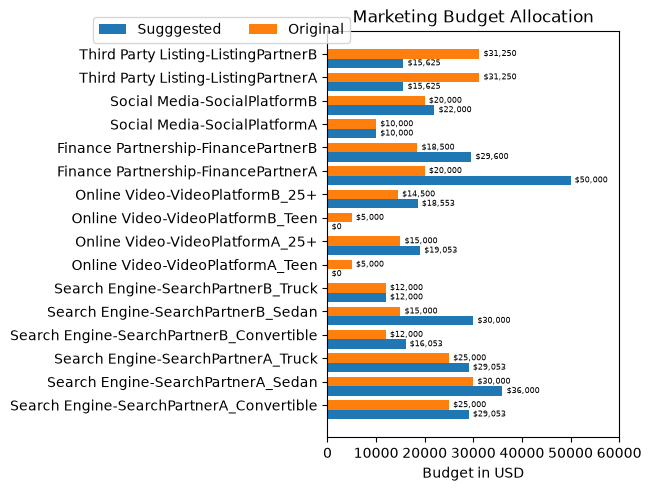

In [25]:
df_final['delta']=[1,1.2,1,1,2,1,0,1,0,1,2.5,1.6,1,1.1,0.5,0.5]
additions = [4053,0,4053,4053,0,0,0,4053,0,4053,0,0,0,0,0,0]
df_final['new_budget'] = round(df_final['total_spend']*df_final['delta'],2)
df_final['new_budget'] =df_final['new_budget'] +additions

# code below adapted from https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html
budgets = {
    'Sugggested': df_final['new_budget'],
    'Original': df_final['total_spend']
}
x = np.arange(len(df_final['channel']))
width = 0.4
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in budgets.items():
    offset = width * multiplier
    rects = ax.barh(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3,fmt='${:,.0f}', fontsize= 6)
    multiplier += 1

ax.set_xlabel('Budget in USD')
ax.set_title('Marketing Budget Allocation')
ax.set_yticks(x + width, df_final['channel'])
ax.legend(loc='upper right', ncols=3,bbox_to_anchor = (.1,1.05),)
plt.xlim(0,60000)

plt.savefig(f"{IMAGES_DIR}/part8_budget_allocation.png", dpi=150, bbox_inches="tight")
plt.show()

0.9268531630243769


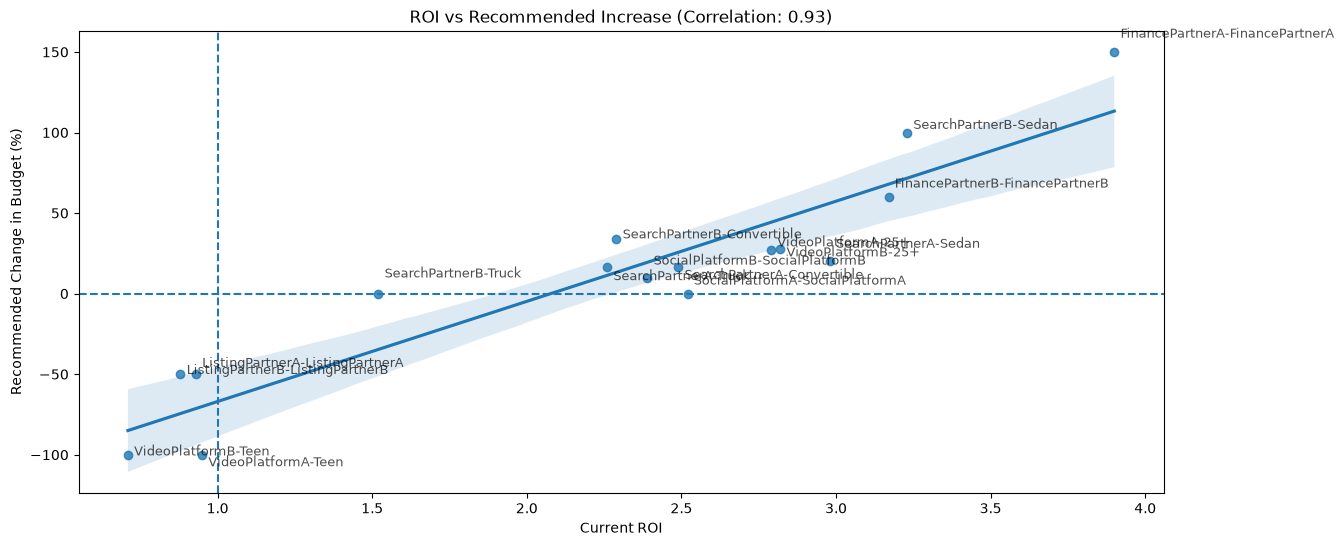

In [26]:
# corr ROI vs new budget
df_final['increase'] = (df_final['new_budget'] /df_final['total_spend'] -1)*100
corr_value = df_final['ROI'].corr(df_final['increase'])
print(corr_value)


## scatter plot
plt.figure(figsize=(14,6))
sns.regplot(
    data=df_final,
    x= 'ROI',
    y = 'increase',
)

for i, row in df_final.iterrows():
    plt.text(
        x= row['ROI'] + 0.02,
        y = row['increase']+ np.random.uniform(-10,10),
        s = row['partner']+'-'+row['campaign'],
        fontsize = 9,
        alpha = 0.7

    )
plt.title(f'ROI vs Recommended Increase (Correlation: {corr_value:.2f})')
plt.ylabel('Recommended Change in Budget (%)')
plt.xlabel('Current ROI')
plt.axhline(y=0, linestyle = '--', label='No Change')
plt.axvline(x=1, linestyle = '--', label='Breakeven')
plt.savefig(f"{IMAGES_DIR}/part9_roi_vs_budget_increase.png", dpi=150, bbox_inches="tight")
plt.show()

0.9268531630243769


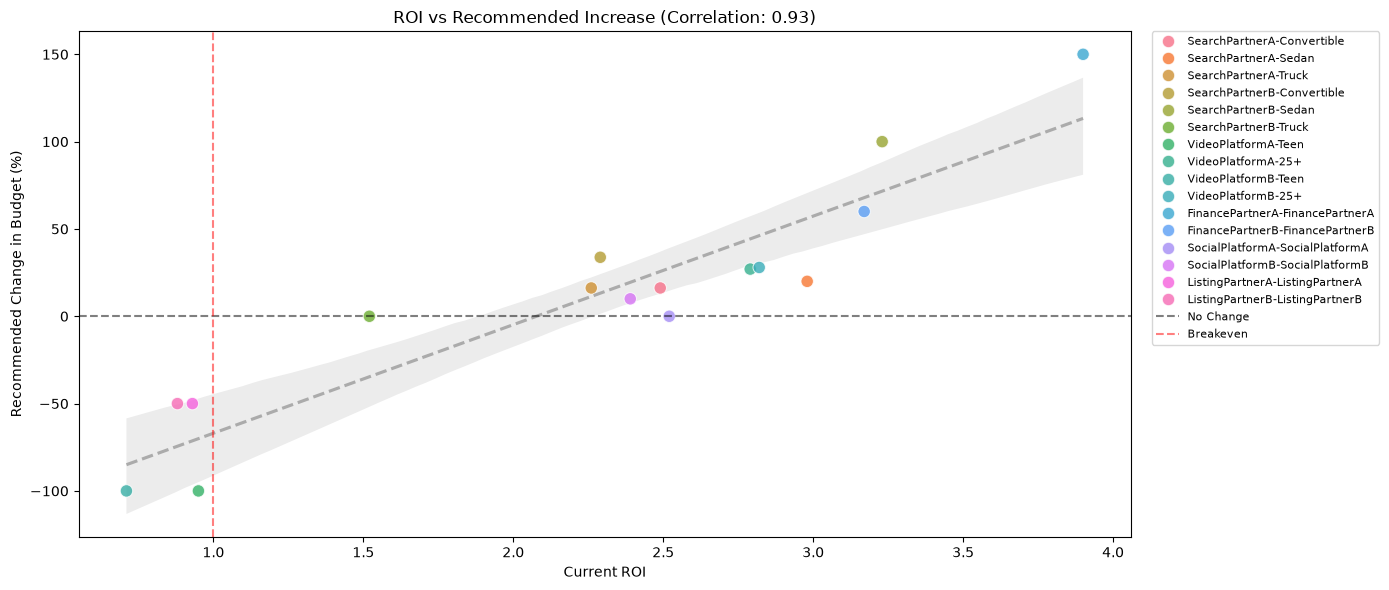

In [28]:
# corr ROI vs new budget
df_final['increase'] = (df_final['new_budget'] / df_final['total_spend'] - 1) * 100
corr_value = df_final['ROI'].corr(df_final['increase'])
print(corr_value)

# combined label for legend
df_final['partner_campaign'] = df_final['partner'] + '-' + df_final['campaign']

# scatter plot
plt.figure(figsize=(14, 6))

sns.regplot(
    data=df_final,
    x='ROI',
    y='increase',
    scatter=False,
    color='gray',
    line_kws={'linestyle': '--', 'alpha': 0.6}
)

sns.scatterplot(
    data=df_final,
    x='ROI',
    y='increase',
    hue='partner_campaign',
    s=80,
    alpha=0.8
)

plt.title(f'ROI vs Recommended Increase (Correlation: {corr_value:.2f})')
plt.ylabel('Recommended Change in Budget (%)')
plt.xlabel('Current ROI')
plt.axhline(y=0, linestyle='--', color='black', alpha=0.5, label='No Change')
plt.axvline(x=1, linestyle='--', color='red', alpha=0.5, label='Breakeven')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/part9_roi_vs_budget_increase.png", dpi=150, bbox_inches="tight")
plt.show()